[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hien078/applied-mathematics-foundation/blob/master/optimization/computation.ipynb)

# Computational Optimization

This notebook implements the core algorithms from [first_principles.md](first_principles.md) **from scratch**,
then validates each result against `scipy.optimize`.

**Contents:**

| # | Topic | Key Algorithm |
|---|-------|---------------|
| 1 | Golden Section Search | 1D bracket-based minimization |
| 2 | Gradient Descent | Steepest descent on Rosenbrock |
| 3 | Newton's Method | Second-order optimization, quadratic vs linear convergence |
| 4 | Step Size Comparison | Fixed step vs Armijo backtracking line search |
| 5 | Convexity Visualization | Convex vs non-convex, local = global theorem |
| 6 | Lagrange Multipliers | Equality-constrained optimization |
| 7 | KKT Conditions | Inequality-constrained optimization |
| 8 | Linear Programming | 2D feasible region, corner points, optimum |
| 9 | Scipy Validation | Cross-check every from-scratch result |

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.colors import LogNorm
import scipy.optimize as opt
from scipy.optimize import minimize, minimize_scalar, linprog

# Plotting defaults
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'lines.linewidth': 1.5,
})

print('All imports successful.')

All imports successful.


---
## 1. Golden Section Search -- 1D Optimization

**Governing principle:** The golden ratio $\varphi = \frac{1+\sqrt{5}}{2}$ allows us to
shrink a bracketing interval while reusing one function evaluation per step.

**Algorithm:**
Given a unimodal function $f$ on $[a, b]$:

1. Compute interior points: $x_1 = b - (b-a)/\varphi$, $x_2 = a + (b-a)/\varphi$
2. If $f(x_1) < f(x_2)$: set $b \leftarrow x_2$ (minimum is in $[a, x_2]$)
3. Else: set $a \leftarrow x_1$ (minimum is in $[x_1, b]$)
4. Repeat until $|b - a| < \varepsilon$

The interval shrinks by a factor of $1/\varphi \approx 0.618$ per iteration.

In [2]:
def golden_section_search(f, a, b, tol=1e-8, max_iter=100):
    """Golden section search for minimum of unimodal f on [a, b].

    Returns:
        x_min: approximate minimizer
        history: list of (a, b) intervals at each step
    """
    phi = (1 + np.sqrt(5)) / 2  # golden ratio ~ 1.618
    resphi = 2 - phi              # ~ 0.382

    history = [(a, b)]

    x1 = a + resphi * (b - a)
    x2 = b - resphi * (b - a)
    f1, f2 = f(x1), f(x2)

    for _ in range(max_iter):
        if abs(b - a) < tol:
            break
        if f1 < f2:
            b = x2
            x2, f2 = x1, f1
            x1 = a + resphi * (b - a)
            f1 = f(x1)
        else:
            a = x1
            x1, f1 = x2, f2
            x2 = b - resphi * (b - a)
            f2 = f(x2)
        history.append((a, b))

    x_min = (a + b) / 2
    return x_min, history


# Test function: f(x) = (x - 2)^2 + sin(5x)
f_1d = lambda x: (x - 2)**2 + np.sin(5 * x)

x_min, history = golden_section_search(f_1d, 0, 4)
print(f'Golden section minimum: x* = {x_min:.10f}')
print(f'                        f(x*) = {f_1d(x_min):.10f}')
print(f'Iterations: {len(history)}')

Golden section minimum: x* = 2.1843532045
                        f(x*) = -0.9632913023
Iterations: 43


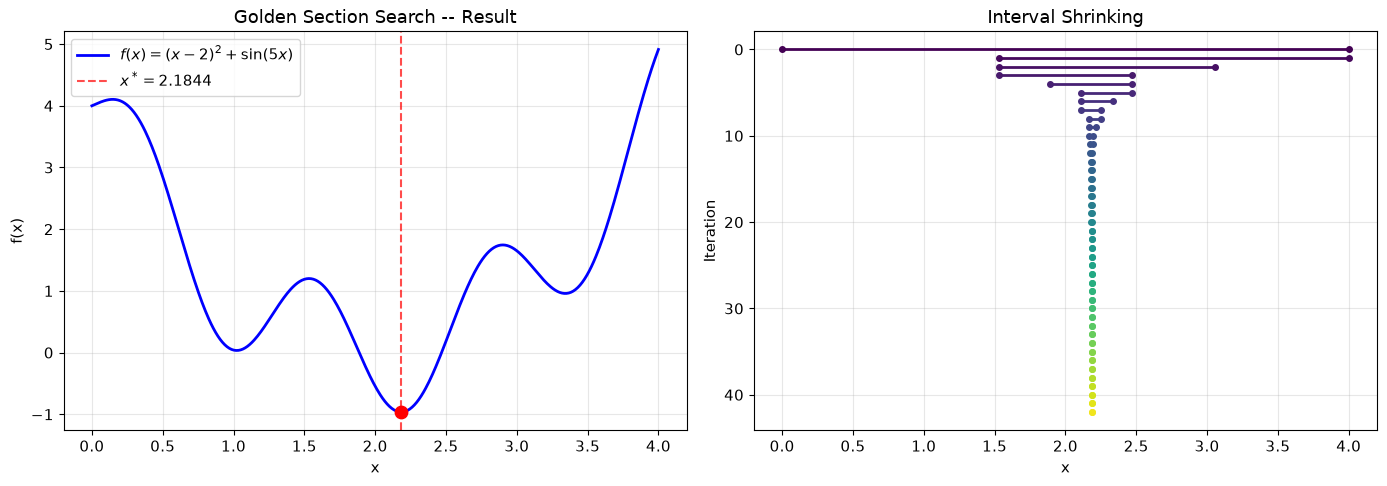

Final interval width: 6.68e-09


In [3]:
# Visualization: interval shrinking
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: function with minimum
x_plot = np.linspace(0, 4, 500)
axes[0].plot(x_plot, f_1d(x_plot), 'b-', lw=2, label=r'$f(x) = (x-2)^2 + \sin(5x)$')
axes[0].axvline(x_min, color='r', ls='--', alpha=0.7, label=f'$x^* = {x_min:.4f}$')
axes[0].scatter([x_min], [f_1d(x_min)], color='red', s=80, zorder=5)
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('Golden Section Search -- Result')
axes[0].legend()

# Right: interval shrinking over iterations
for i, (a, b) in enumerate(history):
    axes[1].plot([a, b], [i, i], 'o-', color=plt.cm.viridis(i / len(history)),
                 markersize=4, lw=2)
axes[1].set_xlabel('x')
axes[1].set_ylabel('Iteration')
axes[1].set_title('Interval Shrinking')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('golden_section_search.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Final interval width: {history[-1][1] - history[-1][0]:.2e}')

---
## 2. Gradient Descent on the Rosenbrock Function

The **Rosenbrock function** is a classic test for optimization algorithms:

$$f(x, y) = (1 - x)^2 + 100(y - x^2)^2$$

- Global minimum at $(x^*, y^*) = (1, 1)$ with $f^* = 0$.
- The narrow curved valley makes gradient descent converge very slowly.

**Gradient:**

$$\nabla f = \begin{pmatrix} -2(1-x) - 400x(y - x^2) \\ 200(y - x^2) \end{pmatrix}$$

**Update rule (gradient descent):**

$$\mathbf{x}_{k+1} = \mathbf{x}_k - \alpha \nabla f(\mathbf{x}_k)$$

In [ ]:
def rosenbrock(xy):
    """Rosenbrock function: f(x,y) = (1-x)^2 + 100*(y-x^2)^2"""
    x, y = xy
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_grad(xy):
    """Gradient of the Rosenbrock function."""
    x, y = xy
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy = 200 * (y - x**2)
    return np.array([dfdx, dfdy])

def gradient_descent(f, grad_f, x0, alpha=1e-3, max_iter=10000, tol=1e-8):
    """Gradient descent with fixed step size.

    Returns:
        x: final point
        trajectory: list of points visited
        f_values: function values at each step
    """
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    f_values = [f(x)]

    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        x = x - alpha * g
        trajectory.append(x.copy())
        f_values.append(f(x))

    return x, np.array(trajectory), np.array(f_values)


# Run gradient descent on Rosenbrock
x0_gd = np.array([-1.0, 1.0])
x_gd, traj_gd, fvals_gd = gradient_descent(rosenbrock, rosenbrock_grad, x0_gd,
                                             alpha=1e-3, max_iter=50000)

print(f'Gradient Descent result:')
print(f'  x* = ({x_gd[0]:.6f}, {x_gd[1]:.6f})')
print(f'  f(x*) = {rosenbrock(x_gd):.6e}')
print(f'  Iterations: {len(traj_gd) - 1}')

Gradient Descent result:
  x* = (1.000000, 1.000000)
  f(x*) = 1.251699e-16
  Iterations: 43564


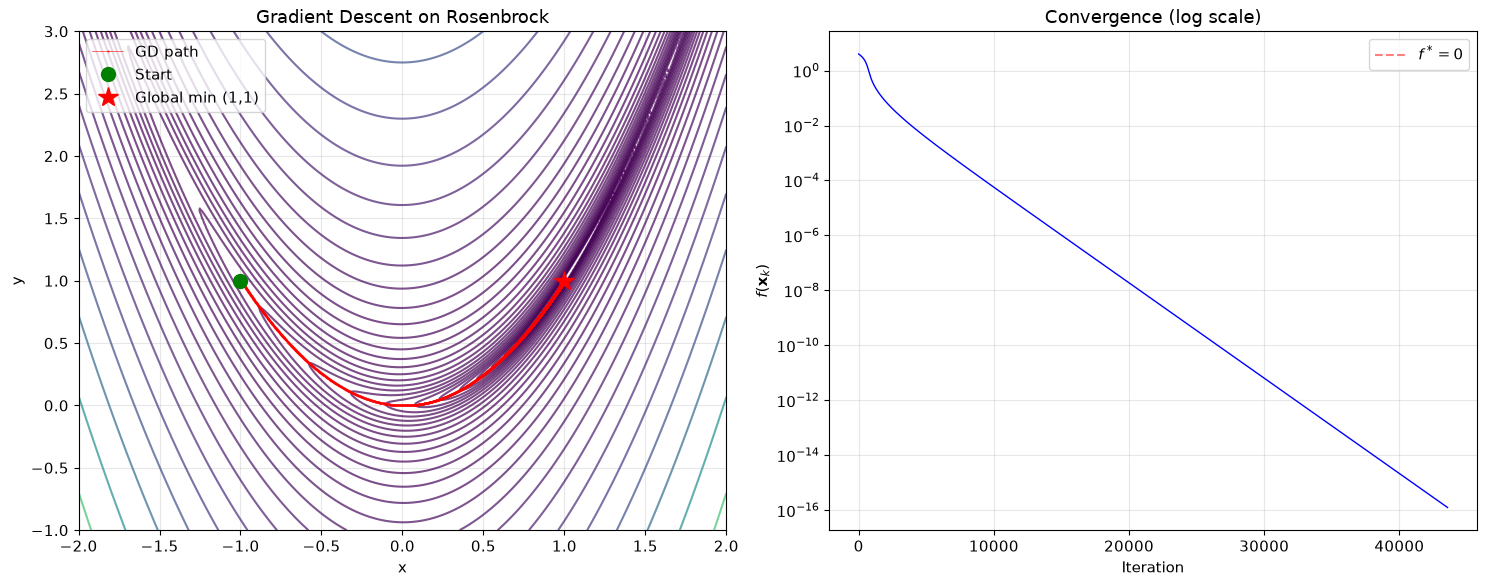

In [5]:
# Contour plot with trajectory + convergence plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Contour plot with GD trajectory
x_range = np.linspace(-2, 2, 300)
y_range = np.linspace(-1, 3, 300)
X, Y = np.meshgrid(x_range, y_range)
Z = (1 - X)**2 + 100 * (Y - X**2)**2

axes[0].contour(X, Y, Z, levels=np.logspace(-1, 3.5, 30), cmap='viridis', alpha=0.7)
axes[0].plot(traj_gd[:, 0], traj_gd[:, 1], 'r.-', markersize=1, lw=0.5,
             alpha=0.8, label='GD path')
axes[0].plot(*x0_gd, 'go', markersize=10, label='Start')
axes[0].plot(1, 1, 'r*', markersize=15, label='Global min (1,1)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Gradient Descent on Rosenbrock')
axes[0].legend(loc='upper left')

# Right: Convergence plot
axes[1].semilogy(fvals_gd, 'b-', lw=1)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$f(\mathbf{x}_k)$')
axes[1].set_title('Convergence (log scale)')
axes[1].axhline(0, color='r', ls='--', alpha=0.5, label='$f^* = 0$')
axes[1].legend()

plt.tight_layout()
plt.savefig('gradient_descent_rosenbrock.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 3. Newton's Method for Optimization

**Update rule:**

$$\mathbf{x}_{k+1} = \mathbf{x}_k - [\nabla^2 f(\mathbf{x}_k)]^{-1} \nabla f(\mathbf{x}_k)$$

Newton's method uses second-order (Hessian) information and converges **quadratically**
near the solution, compared to the **linear** convergence of gradient descent.

**Rosenbrock Hessian:**

$$\nabla^2 f = \begin{pmatrix} 2 + 1200x^2 - 400y & -400x \\ -400x & 200 \end{pmatrix}$$

In [6]:
def rosenbrock_hessian(xy):
    """Hessian of the Rosenbrock function."""
    x, y = xy
    H = np.array([
        [2 + 1200 * x**2 - 400 * y, -400 * x],
        [-400 * x, 200]
    ])
    return H

def newton_optimization(f, grad_f, hess_f, x0, max_iter=100, tol=1e-10):
    """Newton's method for optimization.

    Returns:
        x: final point
        trajectory: list of points visited
        f_values: function values at each step
        grad_norms: gradient norms at each step
    """
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    f_values = [f(x)]
    grad_norms = [np.linalg.norm(grad_f(x))]

    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        H = hess_f(x)
        try:
            dx = np.linalg.solve(H, -g)
        except np.linalg.LinAlgError:
            print(f'Singular Hessian at iteration {k}, stopping.')
            break
        x = x + dx
        trajectory.append(x.copy())
        f_values.append(f(x))
        grad_norms.append(np.linalg.norm(grad_f(x)))

    return x, np.array(trajectory), np.array(f_values), np.array(grad_norms)


# Run Newton's method on Rosenbrock
x0_newton = np.array([-1.0, 1.0])
x_nt, traj_nt, fvals_nt, gnorms_nt = newton_optimization(
    rosenbrock, rosenbrock_grad, rosenbrock_hessian, x0_newton, max_iter=200
)

print(f'Newton\'s method result:')
print(f'  x* = ({x_nt[0]:.10f}, {x_nt[1]:.10f})')
print(f'  f(x*) = {rosenbrock(x_nt):.2e}')
print(f'  Iterations: {len(traj_nt) - 1}')

Newton's method result:
  x* = (1.0000000000, 1.0000000000)
  f(x*) = 6.16e-27
  Iterations: 2


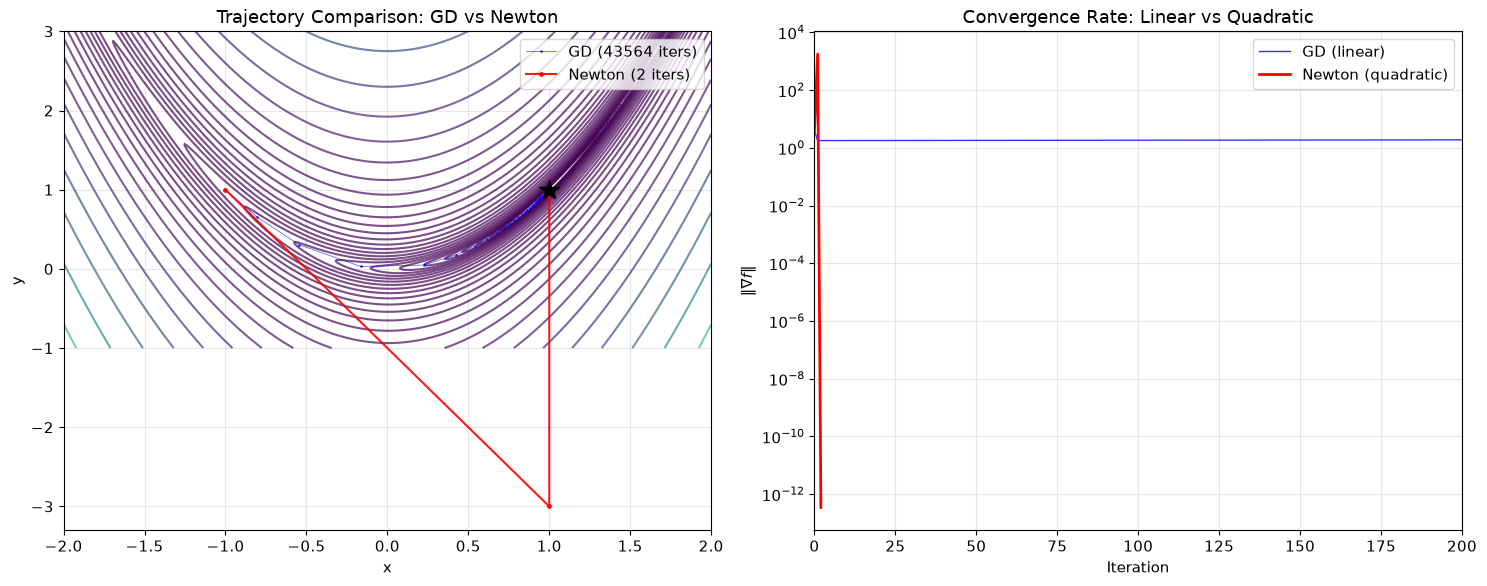


GD final gradient norm:     1.00e-08 after 43564 iterations
Newton final gradient norm: 3.46e-13 after 2 iterations


In [7]:
# Comparison: Newton vs Gradient Descent
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Both trajectories on contour plot
axes[0].contour(X, Y, Z, levels=np.logspace(-1, 3.5, 30), cmap='viridis', alpha=0.7)

# GD trajectory (subsample for clarity)
step = max(1, len(traj_gd) // 200)
axes[0].plot(traj_gd[::step, 0], traj_gd[::step, 1], 'b.-', markersize=2, lw=0.5,
             alpha=0.7, label=f'GD ({len(traj_gd)-1} iters)')
# Newton trajectory
axes[0].plot(traj_nt[:, 0], traj_nt[:, 1], 'r.-', markersize=5, lw=1.5,
             alpha=0.9, label=f"Newton ({len(traj_nt)-1} iters)")
axes[0].plot(1, 1, 'k*', markersize=15, zorder=10)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title("Trajectory Comparison: GD vs Newton")
axes[0].legend()

# Right: Convergence comparison (gradient norm)
gnorms_gd = np.array([np.linalg.norm(rosenbrock_grad(p)) for p in traj_gd])
axes[1].semilogy(gnorms_gd, 'b-', lw=1, alpha=0.8, label='GD (linear)')
axes[1].semilogy(gnorms_nt, 'r-', lw=2, label='Newton (quadratic)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$\|\nabla f\|$')
axes[1].set_title('Convergence Rate: Linear vs Quadratic')
axes[1].legend()
axes[1].set_xlim(0, min(200, len(gnorms_gd)))

plt.tight_layout()
plt.savefig('newton_vs_gd.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nGD final gradient norm:     {gnorms_gd[-1]:.2e} after {len(gnorms_gd)-1} iterations')
print(f'Newton final gradient norm: {gnorms_nt[-1]:.2e} after {len(gnorms_nt)-1} iterations')

---
## 4. Step Size Comparison: Fixed vs Backtracking (Armijo) Line Search

**Armijo condition (sufficient decrease):**

$$f(\mathbf{x}_k + \alpha \mathbf{d}_k) \le f(\mathbf{x}_k) + c_1 \alpha \nabla f(\mathbf{x}_k)^T \mathbf{d}_k$$

where $c_1 \in (0, 1)$ (typically $c_1 = 10^{-4}$) and $\mathbf{d}_k = -\nabla f(\mathbf{x}_k)$.

**Backtracking:** Start with large $\alpha$, reduce by factor $\rho$ until Armijo is satisfied.

In [8]:
def armijo_backtracking(f, grad_f, x, d, alpha_init=1.0, c1=1e-4, rho=0.5):
    """Backtracking line search with Armijo condition.

    Parameters:
        f: objective function
        grad_f: gradient function
        x: current point
        d: search direction
        alpha_init: initial step size
        c1: sufficient decrease parameter
        rho: backtracking factor

    Returns:
        alpha: step size satisfying Armijo condition
    """
    alpha = alpha_init
    fx = f(x)
    gTd = grad_f(x) @ d

    while f(x + alpha * d) > fx + c1 * alpha * gTd:
        alpha *= rho

    return alpha


def gd_with_linesearch(f, grad_f, x0, use_armijo=True, fixed_alpha=1e-3,
                       max_iter=10000, tol=1e-8):
    """Gradient descent with either fixed step or Armijo backtracking."""
    x = np.array(x0, dtype=float)
    trajectory = [x.copy()]
    f_values = [f(x)]

    for k in range(max_iter):
        g = grad_f(x)
        if np.linalg.norm(g) < tol:
            break
        d = -g
        if use_armijo:
            alpha = armijo_backtracking(f, grad_f, x, d)
        else:
            alpha = fixed_alpha
        x = x + alpha * d
        trajectory.append(x.copy())
        f_values.append(f(x))

    return x, np.array(trajectory), np.array(f_values)


# Quadratic test: f(x,y) = 5x^2 + y^2  (condition number kappa = 5)
def f_quad(xy):
    return 5 * xy[0]**2 + xy[1]**2

def grad_quad(xy):
    return np.array([10 * xy[0], 2 * xy[1]])

x0_step = np.array([3.0, 3.0])

# Fixed step size (several values)
alphas_fixed = [0.01, 0.05, 0.1]
results_fixed = {}
for a in alphas_fixed:
    _, traj, fvals = gd_with_linesearch(f_quad, grad_quad, x0_step,
                                         use_armijo=False, fixed_alpha=a,
                                         max_iter=500)
    results_fixed[a] = (traj, fvals)

# Armijo backtracking
_, traj_armijo, fvals_armijo = gd_with_linesearch(f_quad, grad_quad, x0_step,
                                                   use_armijo=True, max_iter=500)

print('Step size comparison on f(x,y) = 5x^2 + y^2:')
for a, (traj, fvals) in results_fixed.items():
    print(f'  Fixed alpha={a:.2f}: {len(traj)-1} iters, f* = {fvals[-1]:.2e}')
print(f'  Armijo backtracking: {len(traj_armijo)-1} iters, f* = {fvals_armijo[-1]:.2e}')

Step size comparison on f(x,y) = 5x^2 + y^2:
  Fixed alpha=0.01: 500 iters, f* = 1.51e-08
  Fixed alpha=0.05: 192 iters, f* = 2.42e-17
  Fixed alpha=0.10: 91 iters, f* = 2.07e-17
  Armijo backtracking: 43 iters, f* = 1.01e-17


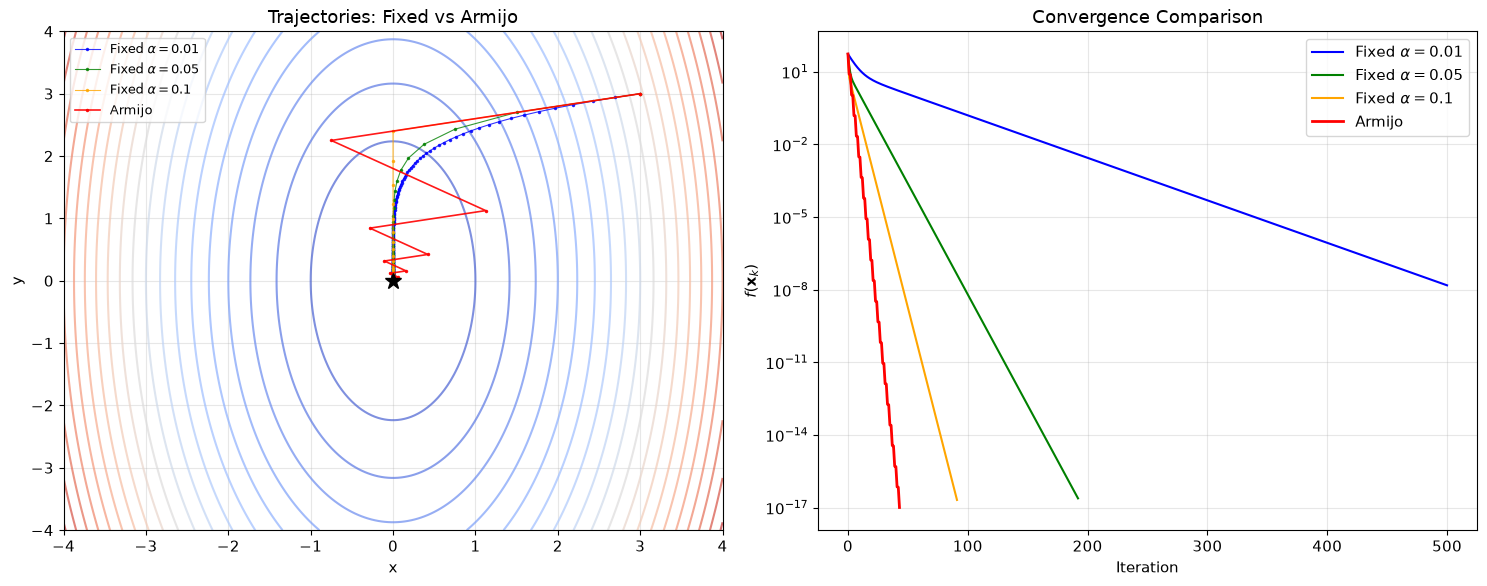

In [9]:
# Visualization
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Left: Contour + trajectories
x_range_q = np.linspace(-4, 4, 200)
y_range_q = np.linspace(-4, 4, 200)
Xq, Yq = np.meshgrid(x_range_q, y_range_q)
Zq = 5 * Xq**2 + Yq**2

axes[0].contour(Xq, Yq, Zq, levels=20, cmap='coolwarm', alpha=0.7)

colors = ['blue', 'green', 'orange']
for (a, (traj, _)), c in zip(results_fixed.items(), colors):
    axes[0].plot(traj[:, 0], traj[:, 1], '.-', color=c, markersize=3, lw=0.8,
                 label=f'Fixed $\\alpha={a}$', alpha=0.8)
axes[0].plot(traj_armijo[:, 0], traj_armijo[:, 1], 'r.-', markersize=3, lw=1.2,
             label='Armijo', alpha=0.9)
axes[0].plot(0, 0, 'k*', markersize=12, zorder=10)
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')
axes[0].set_title('Trajectories: Fixed vs Armijo')
axes[0].legend(fontsize=9)

# Right: Convergence
for (a, (_, fvals)), c in zip(results_fixed.items(), colors):
    axes[1].semilogy(fvals, '-', color=c, lw=1.5, label=f'Fixed $\\alpha={a}$')
axes[1].semilogy(fvals_armijo, 'r-', lw=2, label='Armijo')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel(r'$f(\mathbf{x}_k)$')
axes[1].set_title('Convergence Comparison')
axes[1].legend()

plt.tight_layout()
plt.savefig('step_size_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. Convexity Visualization

**Key theorem:** For convex functions, every local minimum is a global minimum.

$$f \text{ convex} \iff \nabla^2 f(\mathbf{x}) \succeq 0 \;\;\forall\, \mathbf{x}$$

We demonstrate this by comparing optimization on convex vs non-convex functions
with multiple random starting points.

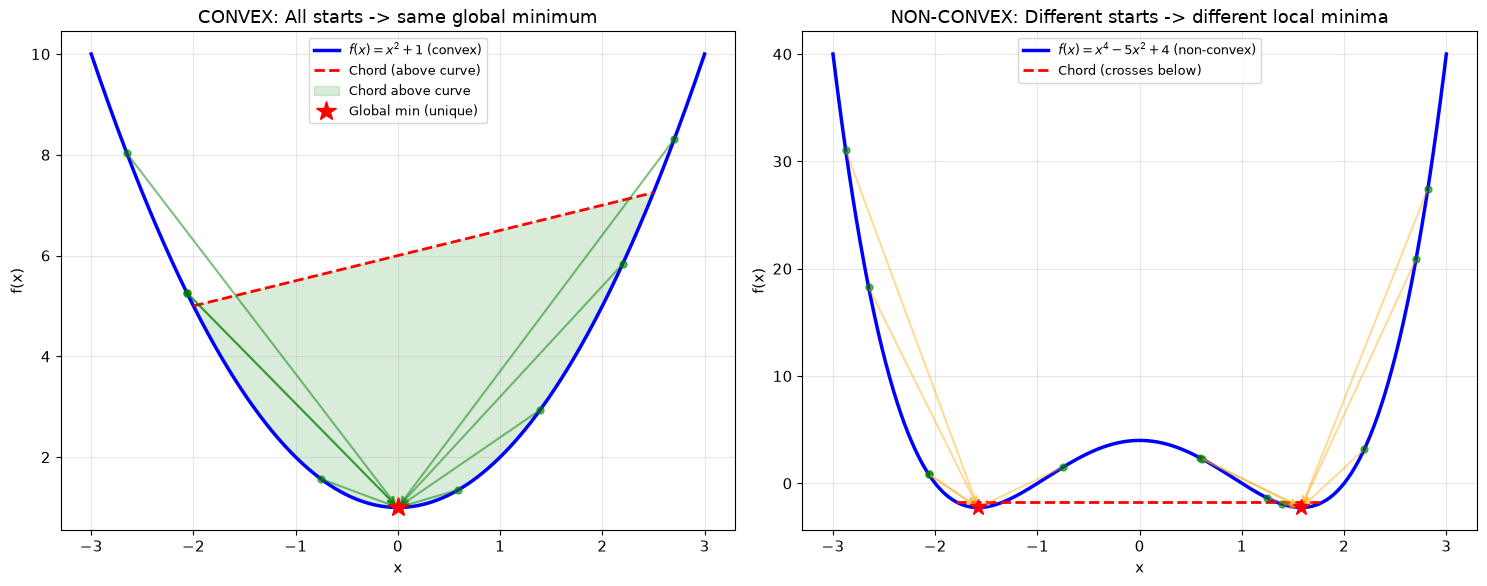

Convexity check via second derivative:
  f(x) = x^2 + 1:       f''(x) = 2 > 0 everywhere -> CONVEX
  f(x) = x^4 - 5x^2 + 4: f''(x) = 12x^2 - 10, changes sign -> NON-CONVEX
    f''(0) = -10 < 0  (non-convex region)
    f''(2) = 38 > 0   (locally convex)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Convex function: f(x) = x^2 + 1 ----
x = np.linspace(-3, 3, 500)
f_convex = x**2 + 1

ax = axes[0]
ax.plot(x, f_convex, 'b-', lw=2.5, label=r'$f(x) = x^2 + 1$ (convex)')

# Show chord property: pick two points, chord lies above the function
x1, x2 = -2.0, 2.5
ax.plot([x1, x2], [x1**2 + 1, x2**2 + 1], 'r--', lw=2, label='Chord (above curve)')
ax.fill_between(x, f_convex,
                np.interp(x, [x1, x2], [x1**2 + 1, x2**2 + 1]),
                where=(x >= x1) & (x <= x2) &
                      (np.interp(x, [x1, x2], [x1**2 + 1, x2**2 + 1]) >= f_convex),
                alpha=0.15, color='green', label='Chord above curve')

# Multiple starts all converge to same minimum
np.random.seed(42)
starts = np.random.uniform(-3, 3, 8)
for s in starts:
    xi = s
    for _ in range(50):
        xi = xi - 0.1 * 2 * xi  # gradient of x^2 is 2x
    ax.annotate('', xy=(xi, xi**2 + 1), xytext=(s, s**2 + 1),
                arrowprops=dict(arrowstyle='->', color='green', alpha=0.5, lw=1.5))
    ax.plot(s, s**2 + 1, 'go', markersize=5, alpha=0.6)

ax.plot(0, 1, 'r*', markersize=15, zorder=10, label='Global min (unique)')
ax.set_title('CONVEX: All starts -> same global minimum')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=9, loc='upper center')

# ---- Non-convex function: f(x) = x^4 - 5x^2 + 4 ----
f_nonconvex = lambda x: x**4 - 5*x**2 + 4
f_nonconvex_grad = lambda x: 4*x**3 - 10*x

ax = axes[1]
ax.plot(x, f_nonconvex(x), 'b-', lw=2.5, label=r'$f(x) = x^4 - 5x^2 + 4$ (non-convex)')

# Show chord below curve for non-convex region
x1nc, x2nc = -1.8, 1.8
ax.plot([x1nc, x2nc], [f_nonconvex(x1nc), f_nonconvex(x2nc)], 'r--', lw=2,
        label='Chord (crosses below)')

# Multiple starts converge to DIFFERENT local minima
np.random.seed(42)
starts_nc = np.random.uniform(-3, 3, 12)
endpoints = []
for s in starts_nc:
    xi = s
    for _ in range(200):
        g = f_nonconvex_grad(xi)
        xi = xi - 0.01 * g
    endpoints.append(xi)
    ax.annotate('', xy=(xi, f_nonconvex(xi)), xytext=(s, f_nonconvex(s)),
                arrowprops=dict(arrowstyle='->', color='orange', alpha=0.4, lw=1.5))
    ax.plot(s, f_nonconvex(s), 'go', markersize=5, alpha=0.6)

# Mark local minima
x_local_mins = [-np.sqrt(2.5), np.sqrt(2.5)]
for xm in x_local_mins:
    ax.plot(xm, f_nonconvex(xm), 'r*', markersize=12, zorder=10)

ax.set_title('NON-CONVEX: Different starts -> different local minima')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend(fontsize=9, loc='upper center')

plt.tight_layout()
plt.savefig('convexity_visualization.png', dpi=120, bbox_inches='tight')
plt.show()

# Verify convexity via second derivative
print('Convexity check via second derivative:')
print(f'  f(x) = x^2 + 1:       f\'\'(x) = 2 > 0 everywhere -> CONVEX')
print(f'  f(x) = x^4 - 5x^2 + 4: f\'\'(x) = 12x^2 - 10, changes sign -> NON-CONVEX')
print(f'    f\'\'(0) = -10 < 0  (non-convex region)')
print(f'    f\'\'(2) = 38 > 0   (locally convex)')

---
## 6. Lagrange Multipliers -- Equality-Constrained Optimization

**Problem:** Minimize $f(x, y) = x^2 + y^2$ subject to $x + y = 1$.

**Lagrangian:**

$$\mathcal{L}(x, y, \lambda) = x^2 + y^2 + \lambda(x + y - 1)$$

**Necessary conditions:**

$$\frac{\partial \mathcal{L}}{\partial x} = 2x + \lambda = 0 \implies x = -\lambda/2$$
$$\frac{\partial \mathcal{L}}{\partial y} = 2y + \lambda = 0 \implies y = -\lambda/2$$
$$x + y = 1 \implies \lambda = -1$$

**Solution:** $x^* = y^* = 1/2$, $\lambda^* = -1$, $f^* = 1/2$.

Lagrange solution (from scratch):
  x* = 0.5000, y* = 0.5000
  lambda* = -1.0000
  f* = 0.5000


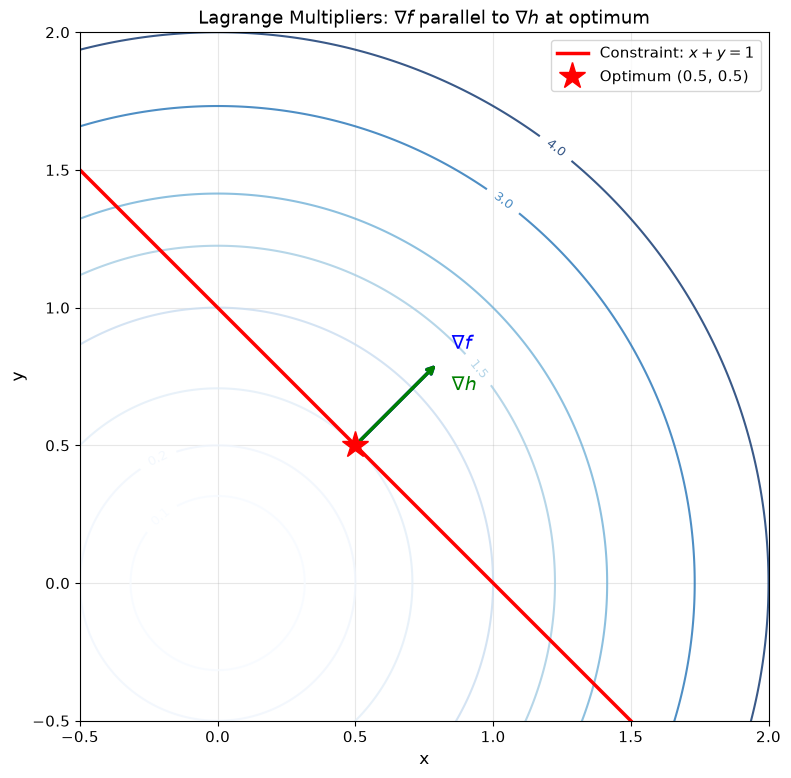


Geometric check: grad_f = [1. 1.], grad_h = [1. 1.]
  grad_f = -1.0 * grad_h = [-1. -1.]
  -> grad_f + lambda * grad_h = [0. 0.] = 0


In [11]:
def solve_lagrange_constrained():
    """Solve min x^2 + y^2 s.t. x + y = 1 using Lagrange conditions directly.

    From the KKT system:
        2x + lambda = 0  =>  x = -lambda/2
        2y + lambda = 0  =>  y = -lambda/2
        x + y = 1        =>  -lambda = 1  =>  lambda = -1
    """
    lam = -1.0
    x_star = -lam / 2
    y_star = -lam / 2
    f_star = x_star**2 + y_star**2
    return x_star, y_star, lam, f_star

x_lag, y_lag, lam_lag, f_lag = solve_lagrange_constrained()
print(f'Lagrange solution (from scratch):')
print(f'  x* = {x_lag:.4f}, y* = {y_lag:.4f}')
print(f'  lambda* = {lam_lag:.4f}')
print(f'  f* = {f_lag:.4f}')

# Visualization: constraint line + level curves + optimal point
fig, ax = plt.subplots(figsize=(8, 8))

# Level curves of f(x,y) = x^2 + y^2
x_range_l = np.linspace(-1, 2, 300)
y_range_l = np.linspace(-1, 2, 300)
Xl, Yl = np.meshgrid(x_range_l, y_range_l)
Fl = Xl**2 + Yl**2

levels = [0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
cs = ax.contour(Xl, Yl, Fl, levels=levels, cmap='Blues', alpha=0.8)
ax.clabel(cs, inline=True, fontsize=9, fmt='%.1f')

# Constraint: x + y = 1
x_constraint = np.linspace(-0.5, 1.5, 200)
y_constraint = 1 - x_constraint
ax.plot(x_constraint, y_constraint, 'r-', lw=2.5, label='Constraint: $x + y = 1$')

# Optimal point
ax.plot(x_lag, y_lag, 'r*', markersize=20, zorder=10,
        label=f'Optimum ({x_lag:.1f}, {y_lag:.1f})')

# Gradient vectors at optimum
scale = 0.3
grad_f = np.array([2 * x_lag, 2 * y_lag])
grad_h = np.array([1.0, 1.0])

ax.annotate('', xy=(x_lag + scale * grad_f[0], y_lag + scale * grad_f[1]),
            xytext=(x_lag, y_lag),
            arrowprops=dict(arrowstyle='->', color='blue', lw=2.5))
ax.text(x_lag + scale * grad_f[0] + 0.05, y_lag + scale * grad_f[1] + 0.05,
        r'$\nabla f$', fontsize=14, color='blue', fontweight='bold')

ax.annotate('', xy=(x_lag + scale * grad_h[0], y_lag + scale * grad_h[1]),
            xytext=(x_lag, y_lag),
            arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax.text(x_lag + scale * grad_h[0] + 0.05, y_lag + scale * grad_h[1] - 0.1,
        r'$\nabla h$', fontsize=14, color='green', fontweight='bold')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title(r'Lagrange Multipliers: $\nabla f$ parallel to $\nabla h$ at optimum',
             fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.set_aspect('equal')
ax.set_xlim(-0.5, 2.0)
ax.set_ylim(-0.5, 2.0)

plt.tight_layout()
plt.savefig('lagrange_multipliers.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'\nGeometric check: grad_f = {grad_f}, grad_h = {grad_h}')
print(f'  grad_f = {lam_lag:.1f} * grad_h = {lam_lag * grad_h}')
print(f'  -> grad_f + lambda * grad_h = {grad_f + lam_lag * grad_h} = 0')

---
## 7. KKT Conditions -- Inequality-Constrained Optimization

**Problem:** Minimize $f(x, y) = (x - 1)^2 + (y - 1)^2$ subject to:
- $g_1: x + y \le 1$
- $g_2: -x \le 0$ (i.e., $x \ge 0$)
- $g_3: -y \le 0$ (i.e., $y \ge 0$)

**KKT conditions:**

1. **Stationarity:** $\nabla f + \mu_1 \nabla g_1 + \mu_2 \nabla g_2 + \mu_3 \nabla g_3 = 0$
2. **Primal feasibility:** $g_i(x,y) \le 0$
3. **Dual feasibility:** $\mu_i \ge 0$
4. **Complementary slackness:** $\mu_i g_i(x,y) = 0$

In [12]:
def verify_kkt():
    """Verify KKT conditions for:
    min (x-1)^2 + (y-1)^2
    s.t. x + y <= 1, x >= 0, y >= 0

    By symmetry and the active constraint x + y = 1, the solution is
    x* = y* = 1/2.
    """
    x_star = np.array([0.5, 0.5])

    # Objective
    f_val = (x_star[0] - 1)**2 + (x_star[1] - 1)**2
    grad_f = np.array([2*(x_star[0] - 1), 2*(x_star[1] - 1)])

    # Constraints in form g_i <= 0
    g1 = x_star[0] + x_star[1] - 1   # x + y - 1 <= 0
    g2 = -x_star[0]                    # -x <= 0
    g3 = -x_star[1]                    # -y <= 0

    grad_g1 = np.array([1, 1])
    grad_g2 = np.array([-1, 0])
    grad_g3 = np.array([0, -1])

    # mu2 = mu3 = 0 (inactive), mu1 = 1 (from stationarity)
    mu1 = 1.0
    mu2 = 0.0
    mu3 = 0.0

    print('=' * 60)
    print('KKT VERIFICATION')
    print('=' * 60)

    # 1. Stationarity
    stationarity = grad_f + mu1 * grad_g1 + mu2 * grad_g2 + mu3 * grad_g3
    print(f'\n1. Stationarity:')
    print(f'   grad_f = {grad_f}')
    print(f'   mu1 * grad_g1 = {mu1 * grad_g1}')
    print(f'   Sum = {stationarity}')
    print(f'   Satisfied: {np.allclose(stationarity, 0)}')

    # 2. Primal feasibility
    print(f'\n2. Primal feasibility:')
    print(f'   g1 = x+y-1 = {g1:.4f} <= 0: {g1 <= 1e-10}')
    print(f'   g2 = -x    = {g2:.4f} <= 0: {g2 <= 1e-10}')
    print(f'   g3 = -y    = {g3:.4f} <= 0: {g3 <= 1e-10}')

    # 3. Dual feasibility
    print(f'\n3. Dual feasibility:')
    print(f'   mu1 = {mu1:.4f} >= 0: {mu1 >= 0}')
    print(f'   mu2 = {mu2:.4f} >= 0: {mu2 >= 0}')
    print(f'   mu3 = {mu3:.4f} >= 0: {mu3 >= 0}')

    # 4. Complementary slackness
    print(f'\n4. Complementary slackness:')
    print(f'   mu1 * g1 = {mu1 * g1:.4f} = 0: {abs(mu1 * g1) < 1e-10}  (g1 active)')
    print(f'   mu2 * g2 = {mu2 * g2:.4f} = 0: {abs(mu2 * g2) < 1e-10}  (mu2 = 0)')
    print(f'   mu3 * g3 = {mu3 * g3:.4f} = 0: {abs(mu3 * g3) < 1e-10}  (mu3 = 0)')

    print(f'\nOptimal solution: x* = {x_star}, f* = {f_val:.4f}')
    print(f'Active constraints: g1 (x + y = 1)')
    print('=' * 60)

    return x_star, f_val, {'mu1': mu1, 'mu2': mu2, 'mu3': mu3}


x_kkt, f_kkt, multipliers = verify_kkt()

KKT VERIFICATION

1. Stationarity:
   grad_f = [-1. -1.]
   mu1 * grad_g1 = [1. 1.]
   Sum = [0. 0.]
   Satisfied: True

2. Primal feasibility:
   g1 = x+y-1 = 0.0000 <= 0: True
   g2 = -x    = -0.5000 <= 0: True
   g3 = -y    = -0.5000 <= 0: True

3. Dual feasibility:
   mu1 = 1.0000 >= 0: True
   mu2 = 0.0000 >= 0: True
   mu3 = 0.0000 >= 0: True

4. Complementary slackness:
   mu1 * g1 = 0.0000 = 0: True  (g1 active)
   mu2 * g2 = -0.0000 = 0: True  (mu2 = 0)
   mu3 * g3 = -0.0000 = 0: True  (mu3 = 0)

Optimal solution: x* = [0.5 0.5], f* = 0.5000
Active constraints: g1 (x + y = 1)


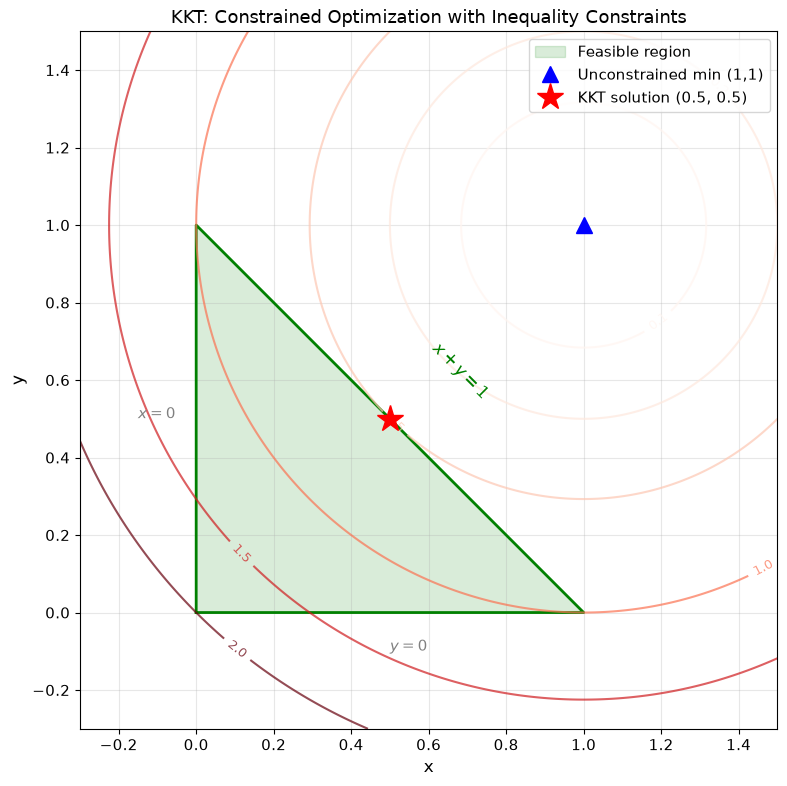

In [13]:
# Visualization of KKT solution
fig, ax = plt.subplots(figsize=(8, 8))

# Feasible region: x + y <= 1, x >= 0, y >= 0
vertices = np.array([[0, 0], [1, 0], [0, 1], [0, 0]])
ax.fill(vertices[:, 0], vertices[:, 1], alpha=0.15, color='green', label='Feasible region')
ax.plot(vertices[:, 0], vertices[:, 1], 'g-', lw=2)

# Level curves of f(x,y) = (x-1)^2 + (y-1)^2
x_range_k = np.linspace(-0.3, 1.5, 300)
y_range_k = np.linspace(-0.3, 1.5, 300)
Xk, Yk = np.meshgrid(x_range_k, y_range_k)
Fk = (Xk - 1)**2 + (Yk - 1)**2

levels_kkt = [0.1, 0.25, 0.5, 1.0, 1.5, 2.0]
cs = ax.contour(Xk, Yk, Fk, levels=levels_kkt, cmap='Reds', alpha=0.7)
ax.clabel(cs, inline=True, fontsize=9, fmt='%.1f')

# Unconstrained minimum
ax.plot(1, 1, 'b^', markersize=12, label='Unconstrained min (1,1)')

# Constrained minimum (KKT solution)
ax.plot(x_kkt[0], x_kkt[1], 'r*', markersize=20, zorder=10,
        label=f'KKT solution ({x_kkt[0]:.1f}, {x_kkt[1]:.1f})')

# Label constraints
ax.text(0.6, 0.55, '$x+y=1$', fontsize=12, color='green', rotation=-45)
ax.text(-0.15, 0.5, '$x=0$', fontsize=11, color='gray')
ax.text(0.5, -0.1, '$y=0$', fontsize=11, color='gray')

ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_title('KKT: Constrained Optimization with Inequality Constraints', fontsize=13)
ax.legend(fontsize=11, loc='upper right')
ax.set_aspect('equal')
ax.set_xlim(-0.3, 1.5)
ax.set_ylim(-0.3, 1.5)

plt.tight_layout()
plt.savefig('kkt_conditions.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 8. Linear Programming -- 2D Feasible Region and Optimal Solution

**Problem (from theory.md Section 5.5):**

$$\max \; 3x_1 + 5x_2$$
$$\text{s.t.} \quad x_1 + 2x_2 \le 8 \quad \text{(labor)}$$
$$\quad\quad\; 2x_1 + x_2 \le 7 \quad \text{(material)}$$
$$\quad\quad\; x_1, x_2 \ge 0$$

**Fundamental theorem of LP:** The optimum is at a vertex of the feasible polyhedron.

We find all corner points, evaluate the objective at each, and identify the optimum.

In [14]:
def find_lp_corner_points():
    """Find all corner points of the feasible region by solving pairs of
    boundary equations.

    Boundaries:
        x1 + 2*x2 = 8
        2*x1 + x2 = 7
        x1 = 0
        x2 = 0
    """
    corners = []
    labels = []

    # Intersection of x1 + 2*x2 = 8 and 2*x1 + x2 = 7
    A = np.array([[1, 2], [2, 1]])
    b = np.array([8, 7])
    sol = np.linalg.solve(A, b)
    corners.append(sol)
    labels.append('labor & material')

    # Intersection of x1 + 2*x2 = 8 and x1 = 0
    corners.append(np.array([0, 4]))
    labels.append('labor & x1=0')

    # Intersection of 2*x1 + x2 = 7 and x2 = 0
    corners.append(np.array([3.5, 0]))
    labels.append('material & x2=0')

    # Origin
    corners.append(np.array([0, 0]))
    labels.append('origin')

    # Intersection of x1 + 2*x2 = 8 and x2 = 0
    corners.append(np.array([8, 0]))
    labels.append('labor & x2=0')

    # Intersection of 2*x1 + x2 = 7 and x1 = 0
    corners.append(np.array([0, 7]))
    labels.append('material & x1=0')

    # Filter: keep only feasible points
    feasible_corners = []
    feasible_labels = []
    for c, l in zip(corners, labels):
        x1, x2 = c
        if (x1 >= -1e-10 and x2 >= -1e-10 and
            x1 + 2*x2 <= 8 + 1e-10 and
            2*x1 + x2 <= 7 + 1e-10):
            feasible_corners.append(c)
            feasible_labels.append(l)

    return np.array(feasible_corners), feasible_labels


corners, labels = find_lp_corner_points()

# Evaluate objective at each corner
objective = lambda x: 3 * x[0] + 5 * x[1]
obj_values = [objective(c) for c in corners]

print('Corner points and objective values:')
print('-' * 50)
for c, l, v in zip(corners, labels, obj_values):
    print(f'  ({c[0]:5.2f}, {c[1]:5.2f})  {l:20s}  obj = {v:.2f}')

opt_idx = np.argmax(obj_values)
print(f'\nOptimal vertex: ({corners[opt_idx][0]:.2f}, {corners[opt_idx][1]:.2f})')
print(f'Maximum objective value: {obj_values[opt_idx]:.2f}')

Corner points and objective values:
--------------------------------------------------
  ( 2.00,  3.00)  labor & material      obj = 21.00
  ( 0.00,  4.00)  labor & x1=0          obj = 20.00
  ( 3.50,  0.00)  material & x2=0       obj = 10.50
  ( 0.00,  0.00)  origin                obj = 0.00

Optimal vertex: (2.00, 3.00)
Maximum objective value: 21.00


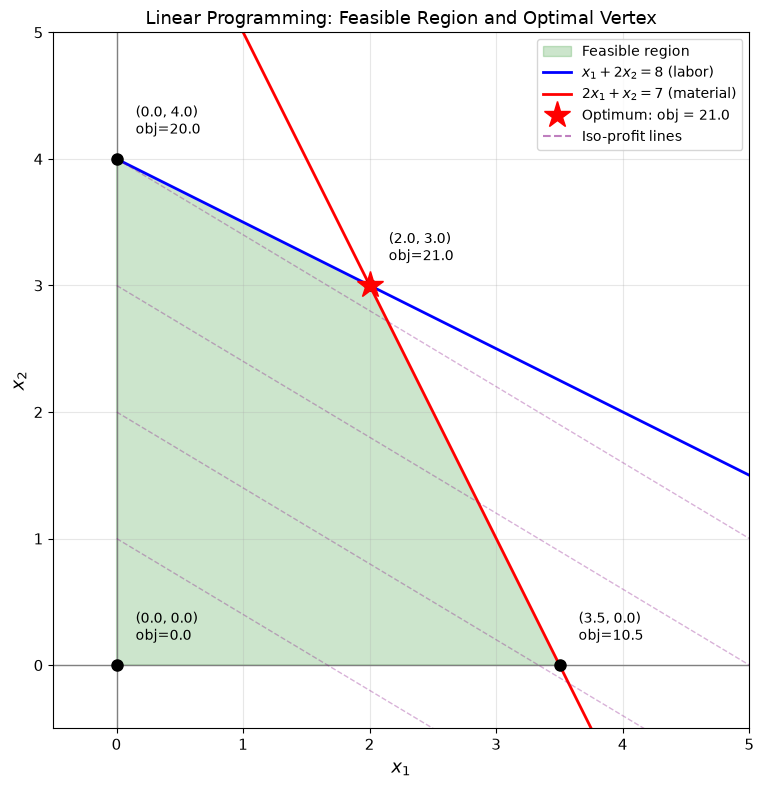

In [15]:
# LP Visualization
fig, ax = plt.subplots(figsize=(9, 8))

# Feasible region polygon
# Order vertices counterclockwise for filling
ordered_corners = np.array([
    [0, 0], [3.5, 0], [corners[0][0], corners[0][1]], [0, 4]
])
polygon = Polygon(ordered_corners, alpha=0.2, color='green', label='Feasible region')
ax.add_patch(polygon)

# Constraint lines
x1_range = np.linspace(0, 5, 500)
y_labor = (8 - x1_range) / 2
y_material = 7 - 2 * x1_range
ax.plot(x1_range, y_labor, 'b-', lw=2, label=r'$x_1 + 2x_2 = 8$ (labor)')
ax.plot(x1_range, y_material, 'r-', lw=2, label=r'$2x_1 + x_2 = 7$ (material)')
ax.axhline(0, color='gray', lw=1)
ax.axvline(0, color='gray', lw=1)

# Corner points
for c, v in zip(corners, obj_values):
    ax.plot(c[0], c[1], 'ko', markersize=8, zorder=10)
    ax.annotate(f'({c[0]:.1f}, {c[1]:.1f})\nobj={v:.1f}',
                xy=(c[0], c[1]), xytext=(c[0]+0.15, c[1]+0.2),
                fontsize=10, ha='left')

# Highlight optimal point
ax.plot(corners[opt_idx][0], corners[opt_idx][1], 'r*', markersize=20, zorder=15,
        label=f'Optimum: obj = {obj_values[opt_idx]:.1f}')

# Iso-profit lines
for z in [5, 10, 15, 20]:
    y_iso = (z - 3 * x1_range) / 5
    ax.plot(x1_range, y_iso, '--', color='purple', alpha=0.3, lw=1)
ax.plot([], [], '--', color='purple', alpha=0.5, label='Iso-profit lines')

ax.set_xlabel(r'$x_1$', fontsize=13)
ax.set_ylabel(r'$x_2$', fontsize=13)
ax.set_title('Linear Programming: Feasible Region and Optimal Vertex', fontsize=13)
ax.legend(fontsize=10, loc='upper right')
ax.set_xlim(-0.5, 5)
ax.set_ylim(-0.5, 5)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig('linear_programming.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 9. Validation with `scipy.optimize`

We validate every from-scratch result against scipy to confirm correctness.

In [16]:
print('=' * 70)
print('SCIPY VALIDATION OF ALL FROM-SCRATCH RESULTS')
print('=' * 70)

# --- 1. Golden Section Search ---
print('\n--- 1. Golden Section Search ---')
res_golden = minimize_scalar(f_1d, bracket=(0, 2, 4), method='golden')
print(f'  From scratch: x* = {x_min:.10f}, f* = {f_1d(x_min):.10f}')
print(f'  Scipy golden: x* = {res_golden.x:.10f}, f* = {res_golden.fun:.10f}')
print(f'  Match: {np.isclose(x_min, res_golden.x, atol=1e-6)} '
      f'(|diff| = {abs(x_min - res_golden.x):.2e})')

# --- 2. Gradient Descent on Rosenbrock ---
print('\n--- 2. Gradient Descent on Rosenbrock ---')
from scipy.optimize import rosen, rosen_der
res_rosen = minimize(rosen, x0=[-1.0, 1.0], jac=rosen_der, method='BFGS')
print(f'  From scratch GD:  x* = ({x_gd[0]:.6f}, {x_gd[1]:.6f}), f* = {rosenbrock(x_gd):.2e}')
print(f'  Scipy BFGS:       x* = ({res_rosen.x[0]:.6f}, {res_rosen.x[1]:.6f}), f* = {res_rosen.fun:.2e}')
print(f'  Known optimum:    x* = (1.000000, 1.000000), f* = 0.0')

# --- 3. Newton's Method ---
print('\n--- 3. Newton\'s Method ---')
res_newton_scipy = minimize(rosen, x0=[-1.0, 1.0], jac=rosen_der, method='Newton-CG',
                             options={'xtol': 1e-10})
print(f'  From scratch Newton: x* = ({x_nt[0]:.10f}, {x_nt[1]:.10f})')
print(f'  Scipy Newton-CG:     x* = ({res_newton_scipy.x[0]:.10f}, {res_newton_scipy.x[1]:.10f})')
print(f'  From scratch f*:  {rosenbrock(x_nt):.2e}')
print(f'  Scipy f*:         {res_newton_scipy.fun:.2e}')

# --- 4. Step Size / Quadratic ---
print('\n--- 4. Quadratic Problem (Step Size Test) ---')
res_quad = minimize(f_quad, x0=[3.0, 3.0], jac=grad_quad, method='BFGS')
x_armijo_final = traj_armijo[-1]
print(f'  Armijo GD:   x* = ({x_armijo_final[0]:.8f}, {x_armijo_final[1]:.8f}), f* = {f_quad(x_armijo_final):.2e}')
print(f'  Scipy BFGS:  x* = ({res_quad.x[0]:.8f}, {res_quad.x[1]:.8f}), f* = {res_quad.fun:.2e}')

# --- 5. Lagrange Multipliers ---
print('\n--- 5. Lagrange Multipliers ---')
res_lag = minimize(lambda xy: xy[0]**2 + xy[1]**2,
                   x0=[0.0, 0.0],
                   constraints={'type': 'eq', 'fun': lambda xy: xy[0] + xy[1] - 1})
print(f'  From scratch: x* = ({x_lag:.4f}, {y_lag:.4f}), f* = {f_lag:.4f}')
print(f'  Scipy SLSQP:  x* = ({res_lag.x[0]:.4f}, {res_lag.x[1]:.4f}), f* = {res_lag.fun:.4f}')
print(f'  Match: {np.allclose([x_lag, y_lag], res_lag.x, atol=1e-4)}')

# --- 6. KKT (Inequality Constrained) ---
print('\n--- 6. KKT (Inequality Constrained) ---')
constraints_kkt = [
    {'type': 'ineq', 'fun': lambda xy: 1 - xy[0] - xy[1]},  # x + y <= 1
]
bounds_kkt = [(0, None), (0, None)]
res_kkt = minimize(lambda xy: (xy[0]-1)**2 + (xy[1]-1)**2,
                   x0=[0.0, 0.0], bounds=bounds_kkt,
                   constraints=constraints_kkt)
print(f'  From scratch KKT: x* = ({x_kkt[0]:.4f}, {x_kkt[1]:.4f}), f* = {f_kkt:.4f}')
print(f'  Scipy SLSQP:      x* = ({res_kkt.x[0]:.4f}, {res_kkt.x[1]:.4f}), f* = {res_kkt.fun:.4f}')
print(f'  Match: {np.allclose(x_kkt, res_kkt.x, atol=1e-4)}')

# --- 7. Linear Programming ---
print('\n--- 7. Linear Programming ---')
# max 3x1 + 5x2  =>  min -3x1 - 5x2
c_lp = [-3, -5]
A_ub_lp = [[1, 2], [2, 1]]
b_ub_lp = [8, 7]
bounds_lp = [(0, None), (0, None)]
res_lp = linprog(c_lp, A_ub=A_ub_lp, b_ub=b_ub_lp, bounds=bounds_lp)
print(f'  From scratch: x* = ({corners[opt_idx][0]:.4f}, {corners[opt_idx][1]:.4f}), '
      f'max obj = {obj_values[opt_idx]:.4f}')
print(f'  Scipy linprog: x* = ({res_lp.x[0]:.4f}, {res_lp.x[1]:.4f}), '
      f'max obj = {-res_lp.fun:.4f}')
print(f'  Match: {np.allclose(corners[opt_idx], res_lp.x, atol=1e-4)}')

print('\n' + '=' * 70)
print('ALL VALIDATIONS COMPLETE')
print('=' * 70)

SCIPY VALIDATION OF ALL FROM-SCRATCH RESULTS

--- 1. Golden Section Search ---
  From scratch: x* = 2.1843532045, f* = -0.9632913023
  Scipy golden: x* = 2.1843532070, f* = -0.9632913023
  Match: True (|diff| = 2.45e-09)

--- 2. Gradient Descent on Rosenbrock ---
  From scratch GD:  x* = (1.000000, 1.000000), f* = 1.25e-16
  Scipy BFGS:       x* = (1.000000, 1.000000), f* = 8.91e-16
  Known optimum:    x* = (1.000000, 1.000000), f* = 0.0

--- 3. Newton's Method ---
  From scratch Newton: x* = (1.0000000000, 1.0000000000)
  Scipy Newton-CG:     x* = (0.9999999998, 0.9999999996)
  From scratch f*:  6.16e-27
  Scipy f*:         3.70e-20

--- 4. Quadratic Problem (Step Size Test) ---
  Armijo GD:   x* = (-0.00000000, 0.00000000), f* = 1.01e-17
  Scipy BFGS:  x* = (-0.00000049, -0.00000138), f* = 3.14e-12

--- 5. Lagrange Multipliers ---
  From scratch: x* = (0.5000, 0.5000), f* = 0.5000
  Scipy SLSQP:  x* = (0.5000, 0.5000), f* = 0.5000
  Match: True

--- 6. KKT (Inequality Constrained) --

---
## Summary

| Algorithm | Implementation | Scipy Check | Key Insight |
|-----------|---------------|-------------|-------------|
| Golden Section Search | From scratch | `minimize_scalar` | Interval shrinks by $1/\varphi$ per step |
| Gradient Descent | From scratch | `minimize(method='BFGS')` | Linear convergence, sensitive to step size |
| Newton's Method | From scratch | `minimize(method='Newton-CG')` | Quadratic convergence near solution |
| Armijo Backtracking | From scratch | -- | Adaptive step ensures sufficient decrease |
| Convexity | Visualization | -- | Convex => local min = global min |
| Lagrange Multipliers | Analytical | `minimize` with `eq` constraint | $\nabla f \parallel \nabla h$ at optimum |
| KKT Conditions | Analytical + verified | `minimize` with bounds + `ineq` | Complementary slackness identifies active constraints |
| Linear Programming | Corner enumeration | `linprog` | Optimum at a vertex (fundamental theorem) |

**Connection to theory.md:** Every algorithm here directly implements the theory from
Sections 2-5 of theory.md. The gradient descent update rule (S2.4), Newton's method (S2.6),
Armijo condition (S2.5), convexity theorem (S3.4), Lagrange conditions (S4.1),
KKT conditions (S4.4), and LP vertex theorem (S5.2) are all computationally verified above.